# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from scipy.cluster.hierarchy import linkage, dendrogram
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Rutas relativas al notebook: funcionan desde cualquier cwd y crean los directorios.
from pathlib import Path
BASE_DIR = Path.cwd().parent
DATA_CLEANED = BASE_DIR / 'data' / 'cleaned'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
DATA_CLEANED.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

### Leer conjunto de datos y primer vistazo

In [2]:
# Leer el csv (esta en 'data/raw/credit_card.csv') y mostrar las primeras filas.
df = pd.read_csv('../data/raw/credit_card.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
# Tamano del dataset.
print(f'Tamaño del dataset: {df.shape[0]} filas y {df.shape[1]} columnas')

Tamaño del dataset: 8950 filas y 18 columnas


In [4]:
# Descripcion estadistica. Fijaos en las escalas tan distintas entre variables.
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
# Tipos de datos.
df.dtypes

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

#### Nulos

In [6]:
# Contar nulos por variable (mostrad solo las que tengan).
nulos = df.isnull().sum()
nulos[nulos > 0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
# 1. Eliminar CUST_ID (es un identificador)
df = df.drop(columns=['CUST_ID'])
# 2. Imputar los nulos con la mediana de cada columna
df = df.fillna(df.median())

# Guardamos el dataset limpio para reutilizarlo en fases posteriores
df.to_parquet(DATA_CLEANED / 'credit_card_cleaned.parquet')

#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

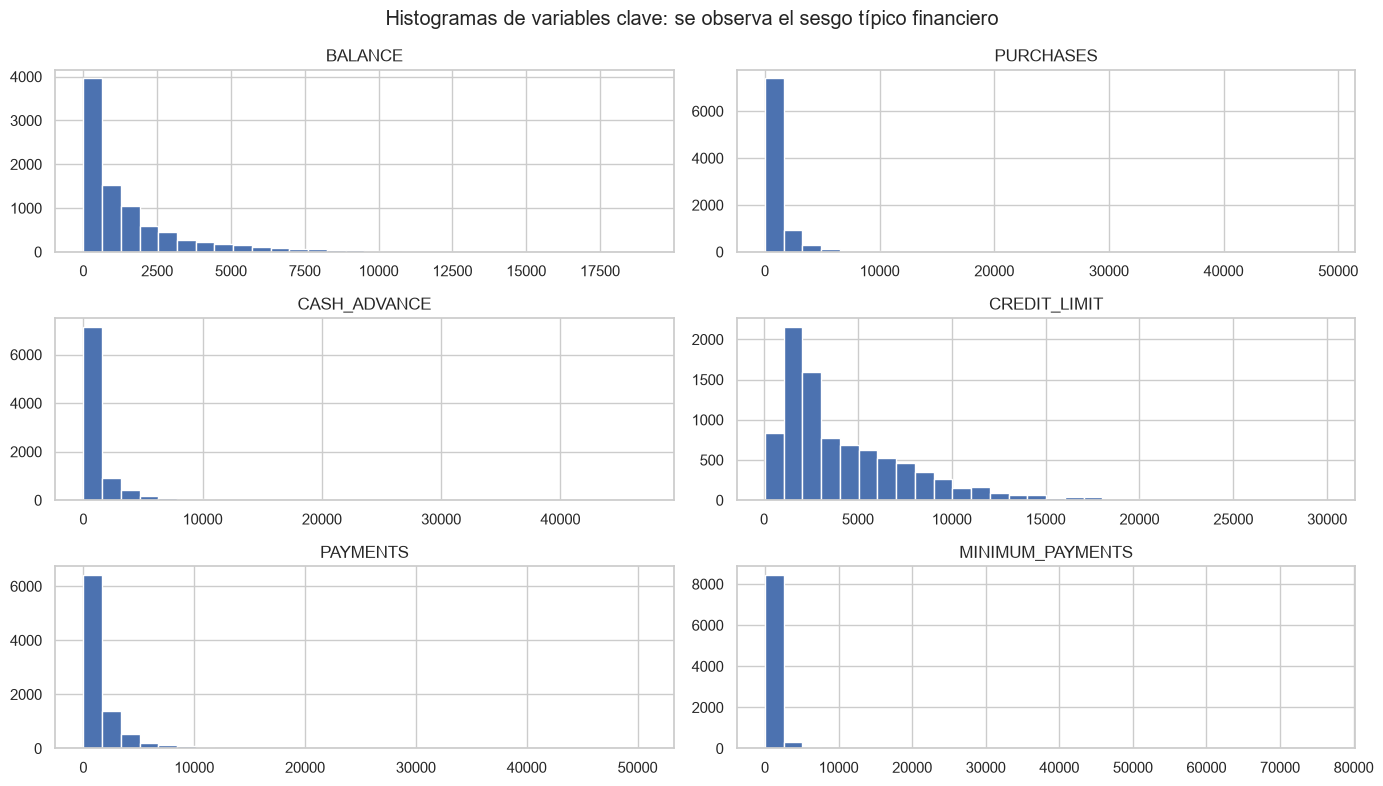

In [8]:
# Pintar histogramas de unas cuantas variables (df[cols].hist...) y observar el sesgo.
cols_hist = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']
df[cols_hist].hist(figsize=(14, 8), bins=30)
plt.suptitle('Histogramas de variables clave: se observa el sesgo típico financiero')
plt.tight_layout()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [9]:
# Aplicar StandardScaler a df -> X (array escalado)
scaler = StandardScaler()
X = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X, columns=df.columns)

# Guardamos el dataset escalado (listo para modelar) para reutilizarlo en fases posteriores
X_scaled.to_parquet(DATA_PROCESSED / 'credit_card_scaled.parquet')

## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

Varianza explicada por componente: [0.273 0.203 0.088 0.075 0.062 0.057 0.049 0.043 0.038 0.031 0.024 0.018
 0.014 0.012 0.01  0.003 0.   ]
Hacen falta 7 componentes para explicar el 80% de la varianza


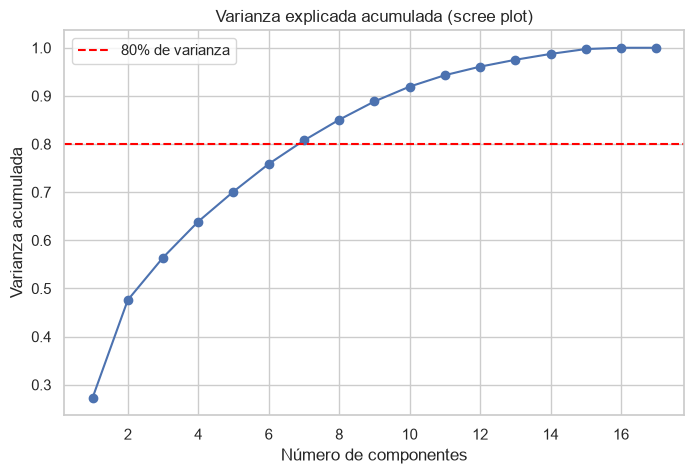

In [10]:
# 1. Ajustar PCA sin fijar n_components y mirar explained_variance_ratio_
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)
print('Varianza explicada por componente:', pca_full.explained_variance_ratio_.round(3))
# 2. Pintar la varianza explicada acumulada (scree plot)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% de varianza')
plt.title('Varianza explicada acumulada (scree plot)')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.legend()
# 3. Decidir cuantas componentes hacen falta para ~80% de varianza
n_80 = np.argmax(cum_var >= 0.80) + 1
print(f'Hacen falta {n_80} componentes para explicar el 80% de la varianza')

Text(0, 0.5, 'PC2')

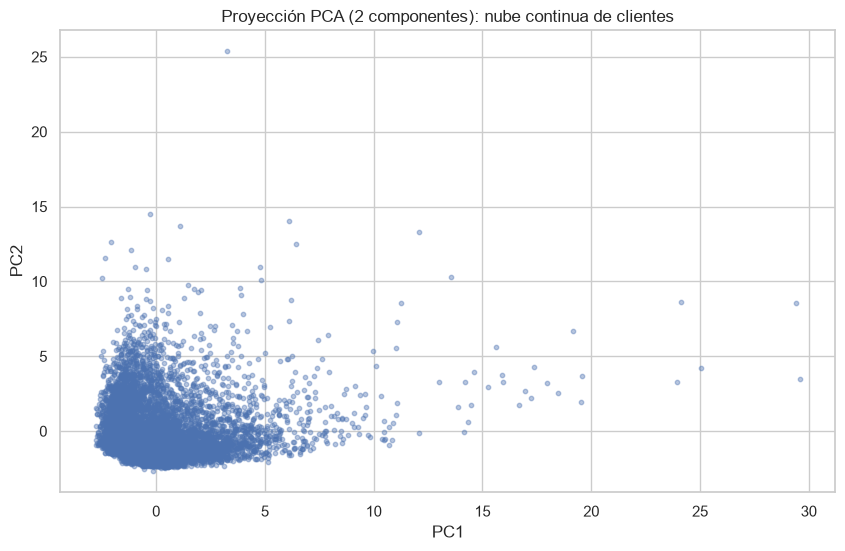

In [11]:
# Proyectar X a 2 componentes y pintar el scatter (aun sin colores: no hay etiqueta)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, s=10)
plt.title('Proyección PCA (2 componentes): nube continua de clientes')
plt.xlabel('PC1')
plt.ylabel('PC2')

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

Mejor k según silhouette: 3 (silhouette = 0.2510)


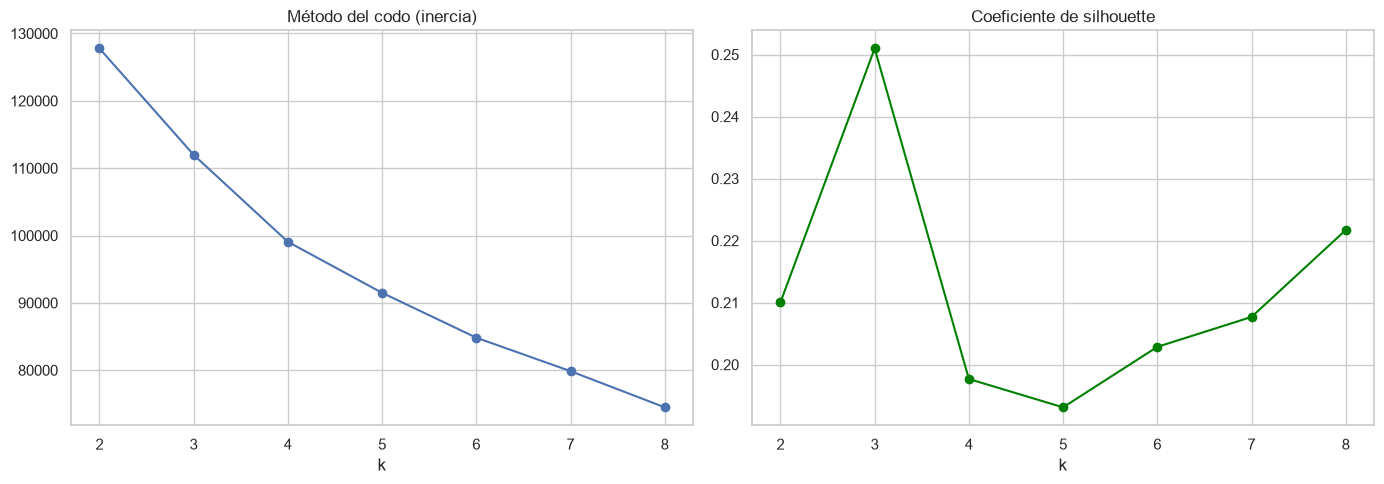

In [12]:
k_values = range(2, 9)
inercias, silhouettes = [], []
for k in k_values:
    # Ajustar KMeans y guardar inercia + silhouette
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Pintar las dos curvas y elegir best_k (el de mayor silhouette)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_values), inercias, marker='o')
ax[0].set_title('Método del codo (inercia)')
ax[0].set_xlabel('k')
ax[1].plot(list(k_values), silhouettes, marker='o', color='green')
ax[1].set_title('Coeficiente de silhouette')
ax[1].set_xlabel('k')
plt.tight_layout()

best_k = k_values[np.argmax(silhouettes)]
print(f'Mejor k según silhouette: {best_k} (silhouette = {max(silhouettes):.4f})')

### K-Means final

In [13]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamano de cada cluster
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X)
labels_km = kmeans.labels_
print('Tamaño de cada cluster:', pd.Series(labels_km).value_counts().sort_index().to_dict())

Tamaño de cada cluster: {0: 1275, 1: 6114, 2: 1561}


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [14]:
# Definir evaluar(nombre, labels, X) con silhouette, davies_bouldin y calinski_harabasz
# (sin ARI: no hay etiqueta). Comparar KMeans, Aglomerativo y GMM.
def evaluar(nombre, labels, X):
    return {
        'modelo': nombre,
        'silhouette': silhouette_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
    }

modelos = {
    'KMeans': kmeans.labels_,
    'Aglomerativo': AgglomerativeClustering(n_clusters=best_k).fit_predict(X),
    'GMM': GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit_predict(X),
}

tabla_comparativa = pd.DataFrame(
    [evaluar(nombre, labels, X) for nombre, labels in modelos.items()]
)
tabla_comparativa

,modelo,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.250988,1.591959,1605.026358
1,Aglomerativo,0.167447,1.849565,1239.325647
2,GMM,0.097797,2.996813,815.782030


### Dendrograma

Text(0, 0.5, 'Distancia')

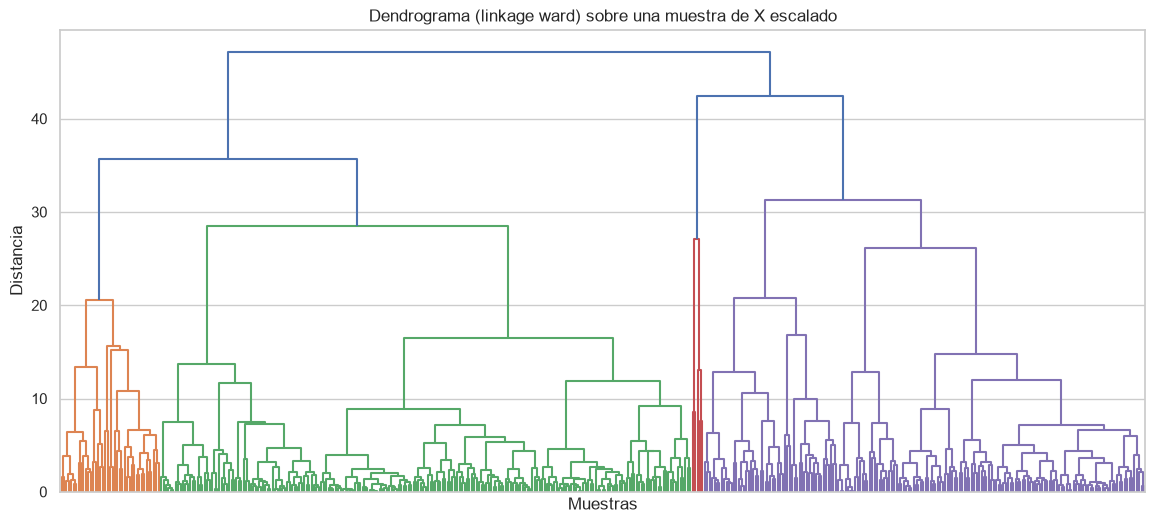

In [15]:
# linkage + dendrogram sobre una muestra de X
X_sample, _ = train_test_split(X, test_size=0.95, random_state=RANDOM_STATE)
Z = linkage(X_sample, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title('Dendrograma (linkage ward) sobre una muestra de X escalado')
plt.xlabel('Muestras')
plt.ylabel('Distancia')

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

In [16]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.
dbscan = DBSCAN(eps=0.5, min_samples=10).fit(X_2d)
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_ruido = (dbscan.labels_ == -1).sum()
print(f'DBSCAN (sobre PCA(2)) -> clusters: {n_clusters} | ruido: {n_ruido} '
      f'({n_ruido / len(dbscan.labels_) * 100:.1f}%)')

DBSCAN (sobre PCA(2)) -> clusters: 4 | ruido: 239 (2.7%)


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

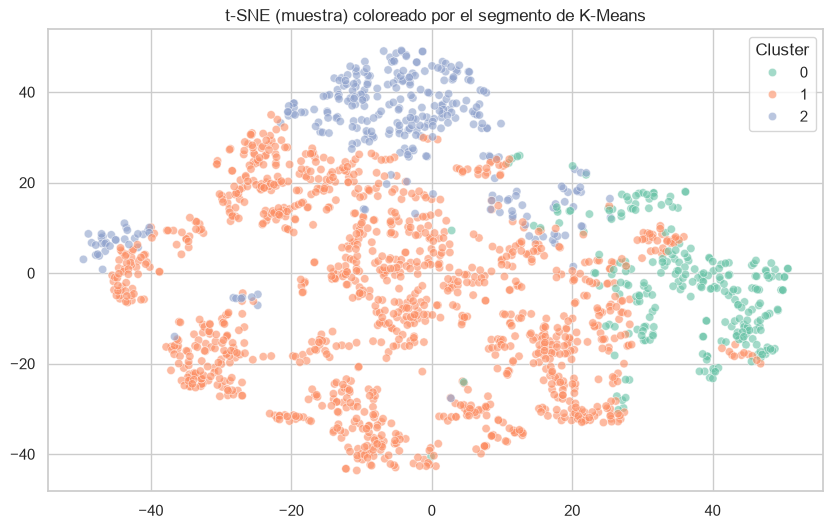

In [17]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans
X_tsne_sample, _, labels_tsne, _ = train_test_split(X, labels_km, test_size=0.8,
                                                    random_state=RANDOM_STATE, stratify=labels_km)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_tsne, palette='Set2', alpha=0.6)
plt.title('t-SNE (muestra) coloreado por el segmento de K-Means')
plt.legend(title='Cluster')

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0        2182.352833           0.981702  4187.017796       2663.995153   
1         807.722510           0.834577   496.062522        247.273214   
2        4023.788865           0.959193   389.051448        252.333261   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                   1523.493231    449.753140             0.948175   
1                    249.110368    338.996760             0.460353   
2                    136.797412   3917.254973             0.233899   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
cluster                                                                 
0                          0.664780                          0.739630   
1                          0.129191                        

Text(0.5, 1.0, 'Perfil de cada segmento (medias estandarizadas entre clusters)')

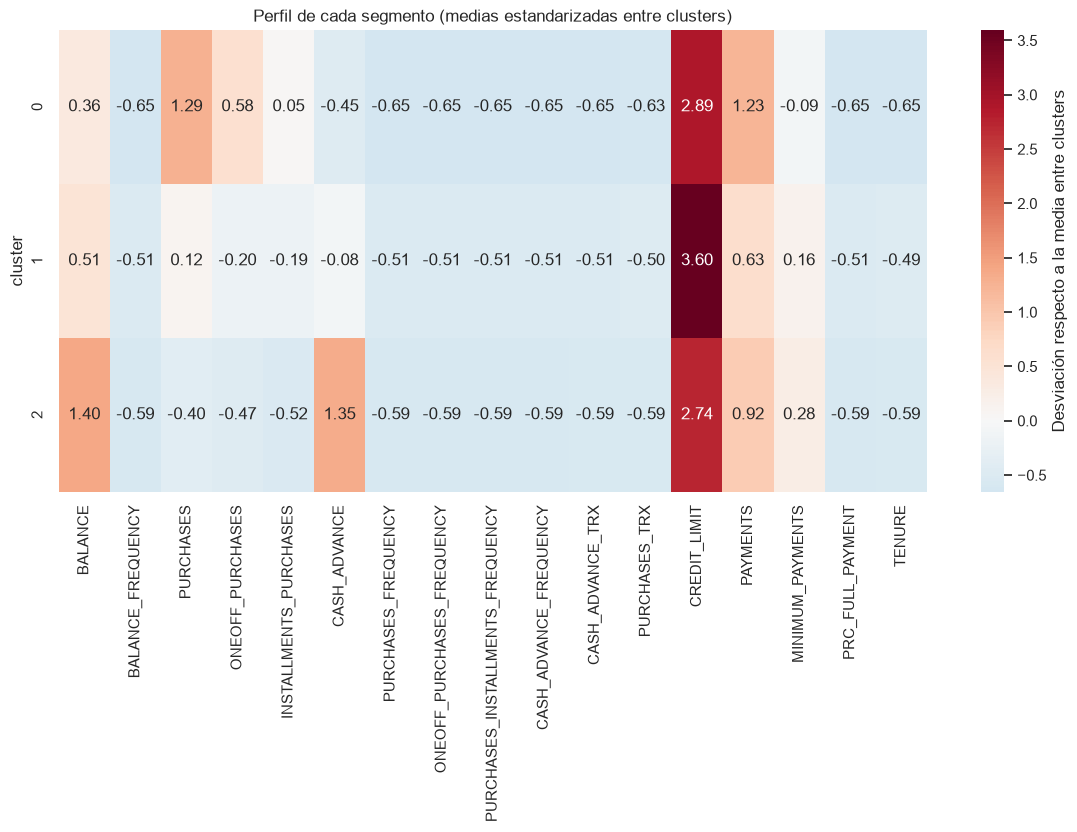

In [18]:
# 1. Anadir la columna 'cluster' al df original (sin escalar)
df_clusters = df.copy()
df_clusters['cluster'] = labels_km

# 2. Calcular la media de cada variable por cluster
perfil_clusters = df_clusters.groupby('cluster').mean()
print(perfil_clusters)

# 3. Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)
perfil_z = perfil_clusters.apply(lambda fila: (fila - fila.mean()) / fila.std(), axis=1)
plt.figure(figsize=(14, 6))
sns.heatmap(perfil_z, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            cbar_kws={'label': 'Desviación respecto a la media entre clusters'})
plt.title('Perfil de cada segmento (medias estandarizadas entre clusters)')

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

In [19]:
# Nombrar cada segmento en terminos de negocio a partir de su perfil estandarizado
def nombre_segmento(fila):
    if fila['PURCHASES'] > 1:
        return 'VIP (grandes compradores)'
    if fila['CASH_ADVANCE'] > 1:
        return 'Riesgo (adelantos de efectivo)'
    if fila['CREDIT_LIMIT'] > 2:
        return 'Alto límite, bajo uso'
    return 'Perfil medio'

nombres_segmentos = perfil_z.apply(nombre_segmento, axis=1)
nombres_segmentos.index.name = 'cluster'
print(nombres_segmentos.to_string())

cluster
0         VIP (grandes compradores)
1             Alto límite, bajo uso
2    Riesgo (adelantos de efectivo)


## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

Número de clientes atípicos: 448


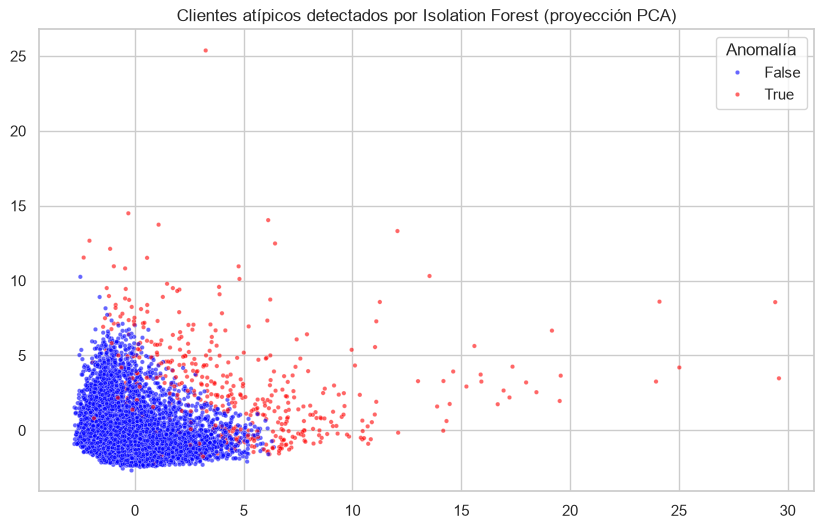

In [20]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_forest.fit(X)
anomalias = iso_forest.predict(X)
print('Número de clientes atípicos:', (anomalias == -1).sum())

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=(anomalias == -1),
                palette={False: 'blue', True: 'red'}, alpha=0.6, s=10)
plt.title('Clientes atípicos detectados por Isolation Forest (proyección PCA)')
plt.legend(title='Anomalía')

---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.